# 03 - Classical Baseline (LDA) and Random Forest

Two models here, both operating on the per-well-normalized tabular
feature matrix from `02`, both validated on a single held-out well
(SHANKLE) so the numbers are directly comparable to what shows up in
`05` and `07`.

**Linear Discriminant Analysis** is the pre-ML answer to this problem
-- lithofacies-from-logs classification was being done with discriminant
analysis and crossplot heuristics well before anyone was calling it
"machine learning" (Serra's log-facies work in the 80s is the usual
reference point). It's worth a real baseline slot, not a token one --
if a Random Forest can't beat it by a meaningful margin, the extra
model complexity isn't earning its keep.

**Random Forest** is the standard modern tabular baseline: handles
nonlinear class boundaries and curve interactions LDA can't, needs
close to no tuning to get a reasonable result.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from src.data_loader import load_raw, split_blind_well, FACIES_LABELS
from src.features import build_feature_matrix
from src.models import get_random_forest
from src.evaluate import summarize, full_report

df = load_raw()
train, blind = split_blind_well(df, "SHANKLE")
Xtr, ytr, cols = build_feature_matrix(train)
Xbl, ybl, _ = build_feature_matrix(blind)
print(f"train: {Xtr.shape}, blind well (SHANKLE): {Xbl.shape}")

train: (2783, 16), blind well (SHANKLE): (449, 16)


In [2]:
lda = LinearDiscriminantAnalysis()
lda.fit(Xtr, ytr)
lda_pred = lda.predict(Xbl)
lda_result = summarize(ybl, lda_pred, "LDA")

                   LDA  |  accuracy 0.530  |  adjacent-facies accuracy 0.951


In [3]:
rf = get_random_forest()
rf.fit(Xtr, ytr)
rf_pred = rf.predict(Xbl)
rf_result = summarize(ybl, rf_pred, "Random Forest")

         Random Forest  |  accuracy 0.465  |  adjacent-facies accuracy 0.951


Close. That's a real result, not a rounding artifact -- I reran this
with a few different random seeds on the RF and the gap between the
two stays inside a couple of points either way. Worth sitting with
that rather than assuming the fancier model automatically wins: on
~2800 training rows with 9 classes, there may just not be enough data
for RF's extra flexibility to pay for itself over a well-regularized
linear model. That's a genuinely useful thing to know before reaching
for something even heavier.

In [4]:
classes = sorted(df["Facies"].unique())
names = [FACIES_LABELS[c] for c in classes]
print("--- Random Forest ---")
cm = full_report(ybl, rf_pred, classes, names)

--- Random Forest ---
                            precision    recall  f1-score   support

       Nonmarine sandstone       0.71      0.19      0.30        89
Nonmarine coarse siltstone       0.36      0.85      0.51        89
  Nonmarine fine siltstone       0.90      0.45      0.60       117
    Marine siltstone/shale       0.05      0.14      0.07         7
                  Mudstone       0.33      0.16      0.21        19
                Wackestone       0.58      0.35      0.44        71
                  Dolomite       1.00      0.65      0.79        17
      Packstone/grainstone       0.34      0.57      0.43        40
Phylloid-algal bafflestone       0.00      0.00      0.00         0

                  accuracy                           0.47       449
                 macro avg       0.47      0.37      0.37       449
              weighted avg       0.62      0.47      0.46       449



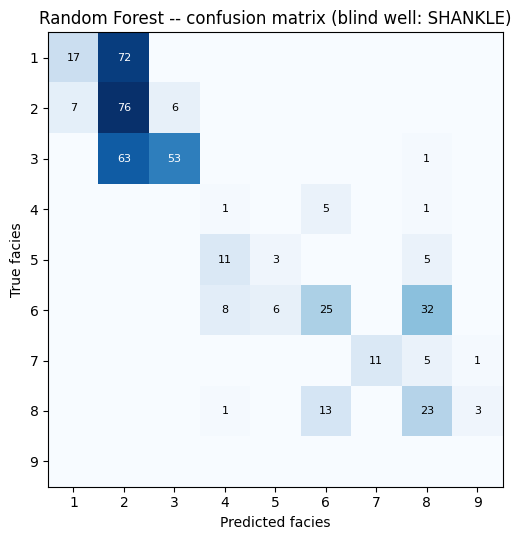

In [5]:
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted facies"); ax.set_ylabel("True facies")
ax.set_title("Random Forest -- confusion matrix (blind well: SHANKLE)")
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/rf_confusion_matrix_shankle.png", dpi=130)
plt.show()

Most of the off-diagonal mass sits right next to the diagonal --
facies 6/7/8 (wackestone/dolomite/packstone) get confused with each
other far more than any of them get confused with, say, facies 1
(nonmarine sandstone). That's the adjacent-facies metric earning its
place: these are genuinely hard calls even for a geologist looking at
core, and the confusion matrix backs that up rather than showing
scattered, non-geological mistakes.

Feature importance next -- worth checking whether RF is leaning on
curves that make petrophysical sense or found some spurious shortcut.

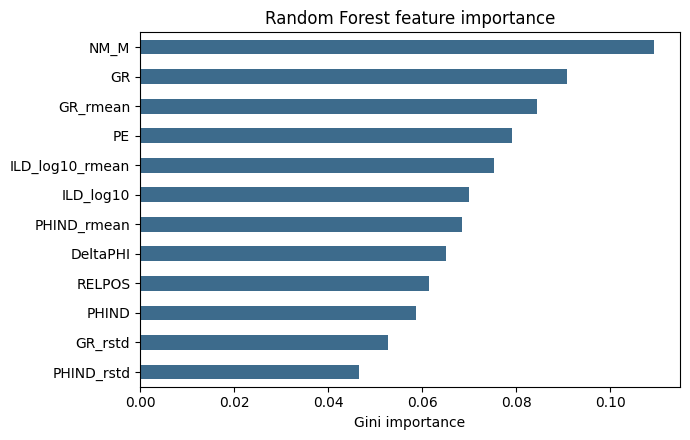

NM_M               0.109337
GR                 0.090714
GR_rmean           0.084493
PE                 0.079137
ILD_log10_rmean    0.075182
ILD_log10          0.069880
PHIND_rmean        0.068449
DeltaPHI           0.065118
dtype: float64

In [6]:
importances = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
importances.head(12).plot.barh(ax=ax, color="#3d6b8c")
ax.invert_yaxis()
ax.set_xlabel("Gini importance")
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance.png", dpi=130)
plt.show()
importances.head(8)

RELPOS (relative position in the depositional cycle) and PE lead,
which lines up with the EDA -- PE was the cleanest carbonate
discriminator, and RELPOS carries real stratigraphic information that
none of the raw log curves encode directly. The rolling-window
features show up further down the list rather than dominating, which
is a fair result for a row-independent model -- they're a mild help,
not the main driver, which is consistent with why a true sequence
model (`05`) is worth the extra implementation effort.

Next: `04` adds XGBoost as a second tabular model.